In [1]:
# ==============================================================
# Isotropic FRB Distribution – Sanity Tests & Mollweide Projection
# ==============================================================

# This script implements:
#   1. Isotropic and dipolar catalog generators
#   2. Mollweide sky projection of a simulated catalog
#   3. Geometric sanity checks on the DEC distribution
#   4. KS uniformity test on sin(DEC)
#   5. Dipole vector estimator (Rayleigh statistic)
#   6. Full p-value calibration under H0 via leave-one-out Monte Carlo
#   7. Statistical scaling of |R| with catalog size N
#   8. Power test: detection rate as a function of dipole amplitude A
# ==============================================================

In [2]:
# ==============================================================
# Libraries
# ==============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from scipy.stats import kstest
import time

In [3]:
# ==============================================================
# Catalog Generators
# ==============================================================

def generate_isotropic_catalog(n_sources, seed=None):
    """
    Generates a single isotropic catalog uniformly distributed over the sphere.

    Sampling strategy:
        RA  ~ Uniform(0, 360)
        DEC = arcsin(2U - 1),  U ~ Uniform(0, 1)
    The arcsin transform ensures uniform solid-angle coverage (equal area per
    declination strip), which is the correct isotropic distribution on S².

    Parameters
    ----------
    n_sources : int
        Number of sources to generate.
    seed : int or None
        Random seed for reproducibility.

    Returns
    -------
    pd.DataFrame with columns ['RA', 'DEC'] in degrees.
    """

    rng = np.random.default_rng(seed)
    ra  = 360.0 * rng.random(n_sources)
    dec = np.degrees(np.arcsin(2.0 * rng.random(n_sources) - 1.0))
    return pd.DataFrame({"RA": ra, "DEC": dec})


def generate_isotropic_ensemble(n_sources, n_realizations, seed=None):
    """
    Generates an ensemble of independent isotropic catalogs (H0 benchmark).

    A single master RNG is used to derive child seeds, ensuring that each
    realization is statistically independent while the entire ensemble remains
    reproducible from a single top-level seed.

    Parameters
    ----------
    n_sources : int
        Number of sources per catalog.
    n_realizations : int
        Number of catalogs in the ensemble.
    seed : int or None
        Master seed for the child seed generator.

    Returns
    -------
    list of pd.DataFrame, each with columns ['RA', 'DEC'] in degrees.
    """

    rng = np.random.default_rng(seed)
    # Draw all child seeds at once to avoid correlations between calls.
    child_seeds = rng.integers(0, int(1e9), size=n_realizations)
    return [generate_isotropic_catalog(n_sources, seed=int(s)) for s in child_seeds]


def generate_dipole_catalog(n_sources, A=0.05, direction=(0, 0), seed=None):
    """
    Generates a catalog with a controlled dipole anisotropy via rejection sampling.

    The acceptance probability follows P(n) ∝ 1 + A*(n · d), where d is the
    unit vector of the dipole axis. Dividing by (1 + |A|) normalizes P so that
    it is a valid probability (≤ 1) for any sky direction.

    Parameters
    ----------
    n_sources : int
        Number of sources to generate.
    A : float
        Dipole amplitude. A=0 recovers isotropy.
    direction : tuple (ra_deg, dec_deg)
        Sky coordinates of the dipole axis in degrees.
    seed : int or None
        Random seed for reproducibility.

    Returns
    -------
    pd.DataFrame with columns ['RA', 'DEC'] in degrees.
    """
    
    rng = np.random.default_rng(seed)

    # Build the dipole axis unit vector in Cartesian coordinates.
    ra_d, dec_d = np.deg2rad(direction)
    d = np.array([
        np.cos(dec_d) * np.cos(ra_d),
        np.cos(dec_d) * np.sin(ra_d),
        np.sin(dec_d)
    ])

    ra_out, dec_out = [], []

    while len(ra_out) < n_sources:
        # Propose a candidate point uniformly on the sphere.
        ra_try  = 360.0 * rng.random()
        dec_try = np.degrees(np.arcsin(2.0 * rng.random() - 1.0))

        # Convert to a Cartesian unit vector.
        phi   = np.deg2rad(ra_try)
        theta = np.deg2rad(dec_try)
        n = np.array([
            np.cos(theta) * np.cos(phi),
            np.cos(theta) * np.sin(phi),
            np.sin(theta)
        ])

        # Accept with probability proportional to the dipole model.
        p = (1.0 + A * np.dot(n, d)) / (1.0 + abs(A))
        if rng.random() < p:
            ra_out.append(ra_try)
            dec_out.append(dec_try)

    return pd.DataFrame({"RA": ra_out, "DEC": dec_out})

In [4]:
# ==============================================================
# Mollweide Sky Projection
# ==============================================================

def plot_mollweide(catalog, title="Isotropic FRB Distribution"):
    """
    Plots the sky distribution of a catalog in Mollweide projection.

    RA is remapped from [0, 2π] to [−π, π] and then negated to follow the
    standard astronomical convention (RA increasing to the left).

    Parameters
    ----------
    catalog : pd.DataFrame
        Catalog with columns ['RA', 'DEC'] in degrees.
    title : str
        Plot title.
    """
    
    ra  = np.radians(catalog["RA"].values)
    dec = np.radians(catalog["DEC"].values)

    # Shift RA from [0, 2π] → [−π, π], then flip for astronomical convention.
    ra = -(ra - np.pi)

    fig = plt.figure(figsize=(12, 6))
    ax  = fig.add_subplot(111, projection="mollweide")
    ax.scatter(ra, dec, s=5, alpha=0.6)
    ax.plot([], [], " ", label=f"$N_{{\\rm FRB}} = {len(catalog)}$")
    ax.legend(loc="upper right", frameon=True)
    ax.set_title(title, pad=26)
    ax.grid(True)
    plt.tight_layout()
    plt.show()

In [5]:
# ==============================================================
# Geometric Sanity Checks on DEC
# ==============================================================

def check_dec_distribution(catalog):
    """
    Plots the raw DEC histogram.

    An isotropic distribution on the sphere produces a cosine-shaped DEC
    histogram (more sources near the equator, fewer near the poles), NOT a
    flat one. A flat histogram would indicate a mistake in the generator.
    """

    plt.figure()
    plt.hist(catalog["DEC"], bins=50)
    plt.xlabel("DEC [deg]")
    plt.ylabel("Count")
    plt.title("DEC Distribution (expected: cosine-shaped)")
    plt.tight_layout()
    plt.show()


def check_sin_dec_distribution(catalog):
    """
    Plots the histogram of sin(DEC).

    Under isotropy, sin(DEC) is exactly Uniform(−1, 1) by construction of
    the arcsin-transform generator. This histogram should be visually flat.
    Any systematic tilt or structure indicates a sampling error.
    """

    sin_dec = np.sin(np.radians(catalog["DEC"]))
    plt.figure()
    plt.hist(sin_dec, bins=50)
    plt.xlabel("sin(DEC)")
    plt.ylabel("Count")
    plt.title("sin(DEC) Distribution (expected: uniform)")
    plt.tight_layout()
    plt.show()

In [6]:
# ==============================================================
# Dipole Vector Estimator (Rayleigh Statistic)
# ==============================================================

def dipole_vector(catalog):
    """
    Computes the mean directional vector R = (1/N) Σ nᵢ over all sources.

    Under isotropy, the unit vectors nᵢ cancel out statistically, so
    |R| ~ O(N^{−1/2}). A significantly large |R| indicates a preferred
    direction (dipole anisotropy).

    Parameters
    ----------
    catalog : pd.DataFrame
        Catalog with columns ['RA', 'DEC'] in degrees.

    Returns
    -------
    R : np.ndarray, shape (3,)
        Mean Cartesian direction vector.
    norm_R : float
        Magnitude |R| (the Rayleigh statistic).
    """

    ra  = np.deg2rad(catalog["RA"].values)
    dec = np.deg2rad(catalog["DEC"].values)
    x = np.cos(dec) * np.cos(ra)
    y = np.cos(dec) * np.sin(ra)
    z = np.sin(dec)
    R = np.array([x.mean(), y.mean(), z.mean()])
    return R, np.linalg.norm(R)


def dipole_pvalue(catalog, iso_ensemble):
    """
    Computes an empirical p-value for the observed dipole amplitude.

    The p-value is the fraction of isotropic realizations whose |R| exceeds
    the observed value. Small p-values (e.g., < 0.05) indicate that the
    observed dipole is unlikely under H0 (isotropy).

    Parameters
    ----------
    catalog : pd.DataFrame
        Observed catalog.
    iso_ensemble : list of pd.DataFrame
        Isotropic benchmark ensemble.

    Returns
    -------
    R_obs : float
        Observed Rayleigh statistic.
    p_value : float
        Empirical p-value.
    R_mc : np.ndarray
        Distribution of |R| under H0.
    """

    _, R_obs = dipole_vector(catalog)
    R_mc     = np.array([dipole_vector(cat)[1] for cat in iso_ensemble])
    p_value  = np.mean(R_mc >= R_obs)
    return R_obs, p_value, R_mc

In [7]:
# ==============================================================
# KS Uniformity Test on sin(DEC)
# ==============================================================

def ks_dec_test(catalog):
    """
    Applies a KS test to verify that sin(DEC) ~ Uniform(−1, 1).

    This is a direct analytical test (no Monte Carlo needed) because the
    theoretical CDF is known exactly. It serves as a quick sanity check on
    the catalog generator.

    Parameters
    ----------
    catalog : pd.DataFrame

    Returns
    -------
    stat : float
        KS statistic D = sup|F_n(x) − F(x)|.
    pvalue : float
        Two-sided p-value. Large values (> 0.05) confirm uniformity.
    """

    u = np.sin(np.deg2rad(catalog["DEC"].values))
    # scipy's 'uniform' is Uniform(loc, loc+scale); here loc=-1, scale=2.
    stat, pvalue = kstest(u, "uniform", args=(-1, 2))
    return stat, pvalue


def ks_dec_pvalue_calibration(iso_ensemble):
    """
    Runs ks_dec_test on every catalog in the ensemble to verify calibration.

    Under H0, p-values from a correctly specified test are Uniform(0, 1).
    Deviations from uniformity indicate a flaw in the generator or test.

    Parameters
    ----------
    iso_ensemble : list of pd.DataFrame

    Returns
    -------
    np.ndarray of p-values, one per catalog.
    """

    return np.array([
        ks_dec_test(cat)[1]
        for cat in tqdm(iso_ensemble, desc="KS(DEC) calibration", unit="catalog")
    ])

In [8]:
# ==============================================================
# P-value Calibration Under H0 (Leave-One-Out)
# ==============================================================

def pvalue_calibration(iso_ensemble):
    """
    Estimates the empirical p-value distribution of the dipole test under H0.

    Each catalog in the ensemble is treated as the 'observed' catalog and
    tested against the remaining N−1 catalogs as the reference. Under a
    well-calibrated test, the resulting p-values are Uniform(0, 1).

    This leave-one-out design avoids circular comparison (a catalog is never
    part of its own reference ensemble), which would deflate p-values.

    Parameters
    ----------
    iso_ensemble : list of pd.DataFrame

    Returns
    -------
    np.ndarray of empirical p-values, one per leave-one-out trial.
    """

    pvals      = []
    n          = len(iso_ensemble)
    start_time = time.time()

    for i, cat in enumerate(tqdm(iso_ensemble, desc="H0 p-value calibration", unit="catalog")):
        # Reference ensemble excludes the current catalog to avoid self-comparison.
        ref = iso_ensemble[:i] + iso_ensemble[i + 1:]
        _, p, _ = dipole_pvalue(cat, ref)
        pvals.append(p)

    elapsed = time.time() - start_time
    print(f"\nCalibration completed in {elapsed / 60:.2f} minutes.")
    return np.array(pvals)


def print_calibration_report(pvals, label="Dipole |R|"):
    """
    Prints a structured KS-based calibration report for a set of p-values.

    Parameters
    ----------
    pvals : np.ndarray
        Empirical p-values from leave-one-out calibration.
    label : str
        Name of the test statistic being reported.
    """
    
    ks_stat, ks_p = kstest(pvals, "uniform")

    print(f"\n{'='*50}")
    print(f"  Calibration Report — {label}")
    print(f"{'='*50}")
    print(f"  KS statistic D : {ks_stat:.4e}")
    print(f"  KS p-value     : {ks_p:.4f}")
    print(f"{'='*50}")
    print("  D = sup_x |F_n(x) − F(x)|")
    print("    F_n : empirical CDF of the p-values")
    print("    F   : CDF of Uniform(0,1)")
    print("  D ≈ 0  → distributions nearly identical")
    print("  D large → systematic deviation from uniformity")
    print(f"{'='*50}")

    if ks_p > 0.95:
        status = "EXCELLENT"
        detail = "p-values are virtually indistinguishable from Uniform(0,1)."
    elif ks_p > 0.05:
        status = "ADEQUATE"
        detail = "p-values are consistent with Uniform(0,1). No significant bias detected."
    else:
        status = "POOR — calibration failure"
        detail = "p-values deviate significantly from uniform. Check for systematic bias."

    print(f"\n  Result        : {status}")
    print(f"  Interpretation: {detail}")
    print(f"  Note          : H0 = isotropy (null hypothesis).")
    print(f"{'='*50}\n")

In [9]:
# ==============================================================
# Statistical Scaling of |R| with N
# ==============================================================

def scaling_with_N(N_values, n_realizations=500):
    """
    Studies how the mean Rayleigh statistic <|R|> scales with catalog size N.

    Under isotropy, the central limit theorem predicts <|R|> ∝ N^{−1/2}.
    Verifying this scaling confirms that the generator is correctly isotropic
    and that the estimator behaves as expected.

    Parameters
    ----------
    N_values : list of int
        Catalog sizes to test.
    n_realizations : int
        Number of isotropic realizations per N value.

    Returns
    -------
    means : np.ndarray
        Mean |R| per N value.
    stds : np.ndarray
        Standard deviation of |R| per N value.
    """

    means, stds = [], []

    for N in tqdm(N_values, desc="Scaling test", unit="N"):
        ensemble = generate_isotropic_ensemble(N, n_realizations)
        R_vals   = np.array([dipole_vector(cat)[1] for cat in ensemble])
        means.append(R_vals.mean())
        stds.append(R_vals.std())

    return np.array(means), np.array(stds)


def plot_scaling(N_values, means, stds):
    """
    Plots <|R|> vs N alongside the theoretical N^{-1/2} scaling.

    The theoretical curve is anchored to the first data point so that the
    shape (slope = −1/2 in log-log) can be compared directly.
    """
    
    N_arr      = np.array(N_values)
    theory     = means[0] * np.sqrt(N_arr[0] / N_arr)  # anchored N^{-1/2}

    plt.figure()
    plt.errorbar(N_arr, means, yerr=stds, fmt="o", label="Measured $\\langle|R|\\rangle$")
    plt.plot(N_arr, theory, "k--", label=r"$N^{-1/2}$ (theory)")
    plt.xscale("log")
    plt.yscale("log")
    plt.xlabel("$N$")
    plt.ylabel(r"$\langle|R|\rangle$")
    plt.title("Rayleigh Statistic Scaling with Catalog Size")
    plt.legend()
    plt.grid(True, which="both", ls=":")
    plt.tight_layout()
    plt.show()

In [10]:
# ==============================================================
# Power Test: Detection Rate vs Dipole Amplitude
# ==============================================================

def dipole_power_test(N, A_values, n_realizations=200, n_benchmark=1000, seed=1):
    """
    Measures the statistical power of the dipole test as a function of A.

    For each amplitude A, 'n_realizations' dipole catalogs are generated and
    tested against a fixed isotropic benchmark. The power is the fraction of
    trials where the test correctly rejects H0 at α = 0.05.

    A fixed benchmark (same seed) is used across all amplitudes so that
    differences in detection rate are attributable solely to A, not to
    benchmark variance.

    Parameters
    ----------
    N : int
        Catalog size.
    A_values : list of float
        Dipole amplitudes to test.
    n_realizations : int
        Number of dipole catalogs per amplitude.
    n_benchmark : int
        Size of the fixed isotropic benchmark ensemble.
    seed : int
        Seed for the benchmark ensemble.

    Returns
    -------
    list of float
        Detection rate (power) per amplitude value.
    """
    
    benchmark  = generate_isotropic_ensemble(N, n_benchmark, seed=seed)
    power      = []
    start_time = time.time()

    for A in tqdm(A_values, desc="Power test — amplitudes", unit="A"):
        detections = 0
        for _ in tqdm(range(n_realizations), desc=f"  A = {A:.3f}", unit="sim", leave=False):
            cat = generate_dipole_catalog(N, A=A)
            _, p, _ = dipole_pvalue(cat, benchmark)
            if p < 0.05:
                detections += 1
        power.append(detections / n_realizations)

    elapsed = time.time() - start_time
    print(f"\nPower test completed in {elapsed / 60:.2f} minutes.")
    return power


def plot_power(A_values, power, N):
    """
    Plots statistical power vs dipole amplitude A.

    The dashed line at power = 0.80 marks the conventional 80% power threshold
    used in sample size calculations. The dotted line at α = 0.05 marks the
    significance level (minimum power under H0).
    """
    plt.figure()
    plt.plot(A_values, power, marker="o", label="Detection rate")
    plt.axhline(0.80, color="gray",  ls="--", lw=1, label="80% power threshold")
    plt.axhline(0.05, color="black", ls=":",  lw=1, label=r"$\alpha = 0.05$")
    plt.xlabel("Dipole amplitude $A$")
    plt.ylabel("Statistical power")
    plt.title(f"Power Test  ($N = {N}$, $\\alpha = 0.05$)")
    plt.ylim(0, 1.05)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

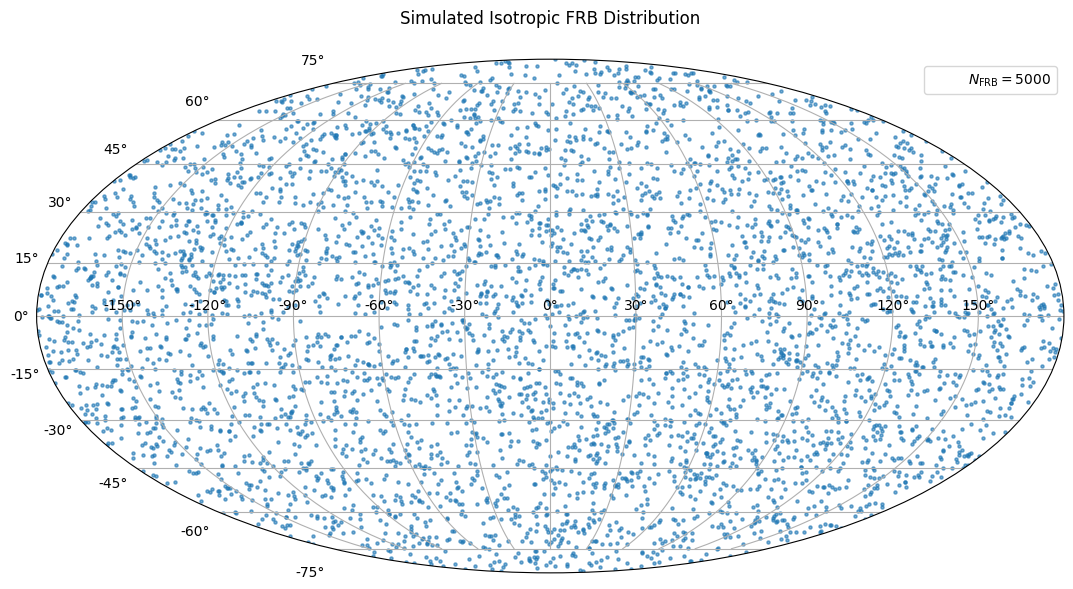

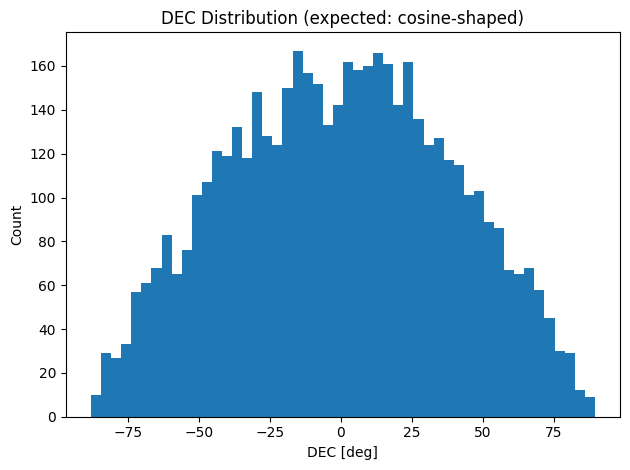

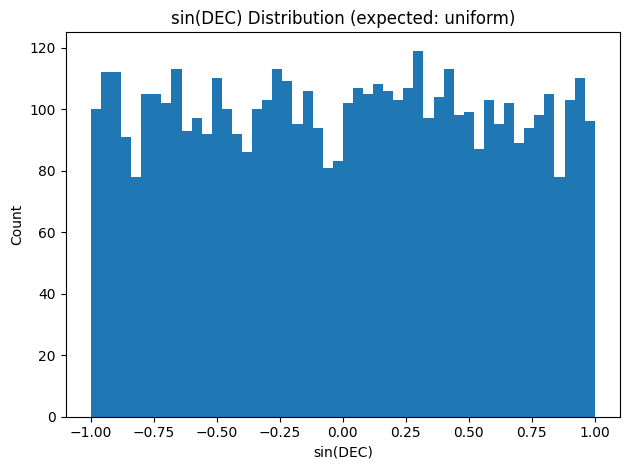


KS test on sin(DEC) [single catalog]:  D = 9.9658e-03,  p = 0.6995


KS(DEC) calibration:   0%|          | 0/1000 [00:00<?, ?catalog/s]


  Calibration Report — KS sin(DEC)
  KS statistic D : 2.7133e-02
  KS p-value     : 0.4454
  D = sup_x |F_n(x) − F(x)|
    F_n : empirical CDF of the p-values
    F   : CDF of Uniform(0,1)
  D ≈ 0  → distributions nearly identical
  D large → systematic deviation from uniformity

  Result        : ADEQUATE
  Interpretation: p-values are consistent with Uniform(0,1). No significant bias detected.
  Note          : H0 = isotropy (null hypothesis).



H0 p-value calibration:   0%|          | 0/1000 [00:00<?, ?catalog/s]


Calibration completed in 4.01 minutes.

  Calibration Report — Dipole |R|
  KS statistic D : 1.0000e-03
  KS p-value     : 1.0000
  D = sup_x |F_n(x) − F(x)|
    F_n : empirical CDF of the p-values
    F   : CDF of Uniform(0,1)
  D ≈ 0  → distributions nearly identical
  D large → systematic deviation from uniformity

  Result        : EXCELLENT
  Interpretation: p-values are virtually indistinguishable from Uniform(0,1).
  Note          : H0 = isotropy (null hypothesis).



Scaling test:   0%|          | 0/5 [00:00<?, ?N/s]

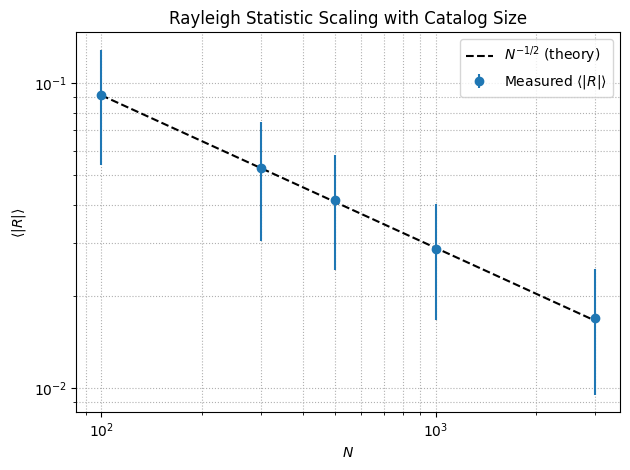

Power test — amplitudes:   0%|          | 0/4 [00:00<?, ?A/s]

  A = 0.010:   0%|          | 0/200 [00:00<?, ?sim/s]

  A = 0.020:   0%|          | 0/200 [00:00<?, ?sim/s]

  A = 0.050:   0%|          | 0/200 [00:00<?, ?sim/s]

  A = 0.100:   0%|          | 0/200 [00:00<?, ?sim/s]


Power test completed in 3.48 minutes.


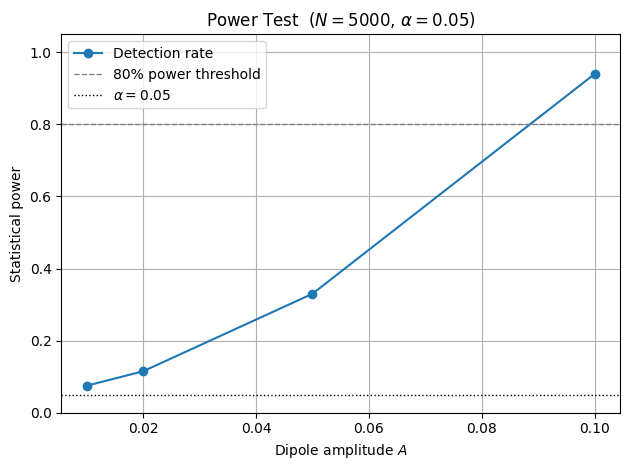

In [11]:
# ==============================================================
# Main Execution
# ==============================================================

N_FRB          = 5_000
N_REALIZATIONS = 1_000

# --- Catalogs ---
iso_catalog  = generate_isotropic_catalog(n_sources=N_FRB, seed=42)
iso_ensemble = generate_isotropic_ensemble(n_sources=N_FRB, n_realizations=N_REALIZATIONS, seed=123)

# --- Mollweide projection ---
plot_mollweide(iso_catalog, title="Simulated Isotropic FRB Distribution")

# --- Geometric sanity checks ---
check_dec_distribution(iso_catalog)
check_sin_dec_distribution(iso_catalog)

# --- KS test on sin(DEC): single catalog ---
ks_stat, ks_p = ks_dec_test(iso_catalog)
print(f"\nKS test on sin(DEC) [single catalog]:  D = {ks_stat:.4e},  p = {ks_p:.4f}")

# --- KS calibration over the full ensemble ---
pvals_ks = ks_dec_pvalue_calibration(iso_ensemble)
print_calibration_report(pvals_ks, label="KS sin(DEC)")

# --- Dipole p-value calibration (leave-one-out) ---
pvals_dipole = pvalue_calibration(iso_ensemble)
print_calibration_report(pvals_dipole, label="Dipole |R|")

# --- Scaling test ---
N_vals         = [100, 300, 500, 1_000, 3_000]
mean_R, std_R  = scaling_with_N(N_vals, n_realizations=500)
plot_scaling(N_vals, mean_R, std_R)

# --- Power test ---
A_vals = [0.01, 0.02, 0.05, 0.10]
power  = dipole_power_test(N_FRB, A_vals, n_realizations=200, n_benchmark=1_000, seed=1)
plot_power(A_vals, power, N_FRB)